import libraries

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

Load DataSet

In [142]:
#add column names as it is not found in the data file
columns = [
    'Sex',
    'Length',
    'Diameter',
    'Height',
    'Whole_weight',
    'Shucked_weight',
    'Viscera_weight',
    'Shell_weight',
    'Rings'
]
df = pd.read_csv(
    'abalone.data',
    header=None,#no header in file
    names=columns#use names that i decided
)

In [143]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Understanding Data


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [145]:
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [146]:
df.shape

(4177, 9)

Check for Null values

In [147]:
df.isnull().sum()

,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


Check for duplicated Values

In [148]:
df.duplicated().sum()

np.int64(0)

Add column Age to set it our Target

In [149]:
df['Age']=df['Rings']+1.5

Distribution of Target

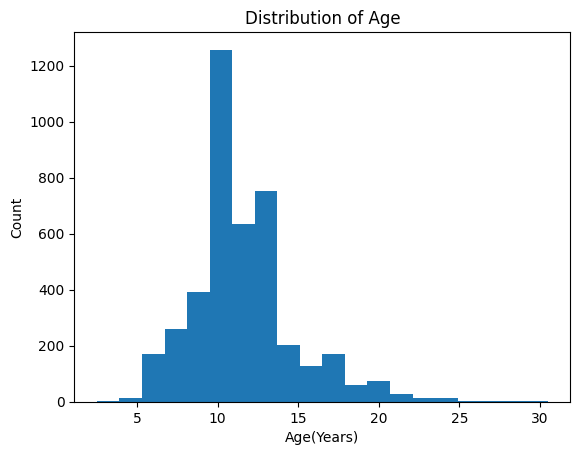

In [150]:
plt.hist(df['Age'],bins=20)
plt.xlabel('Age(Years)')
plt.ylabel('Count')
plt.title('Distribution of Age')
plt.show()
#if bins too low it will hide actual shape if too high it will look noisy

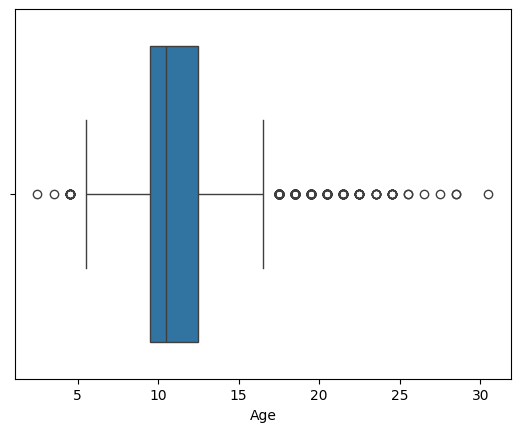

In [151]:
sns.boxplot(x=df['Age'])
plt.show()

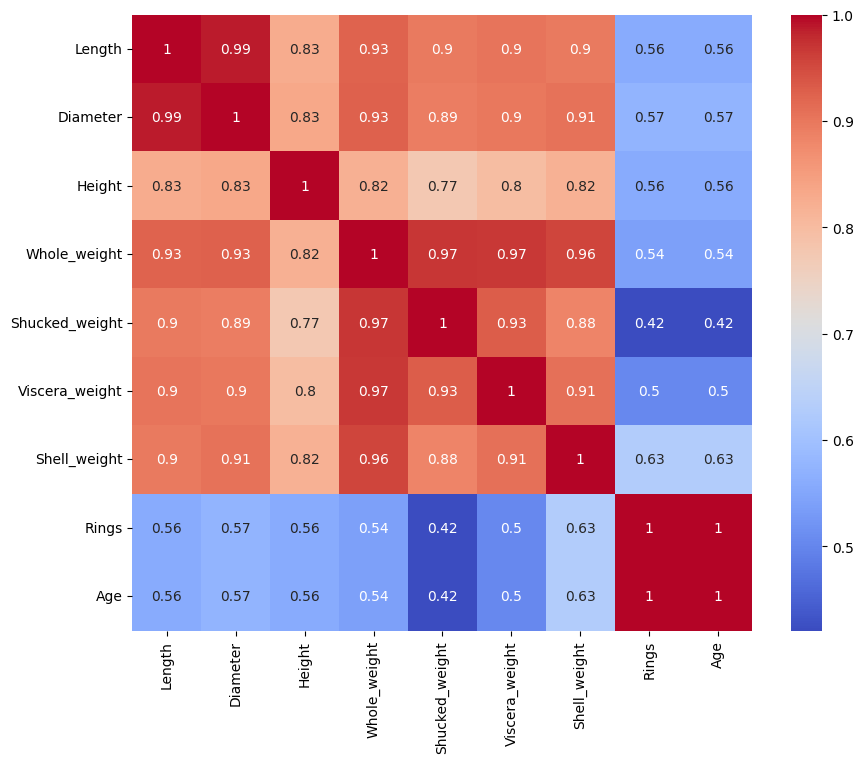

In [152]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.show()
#see the correlations

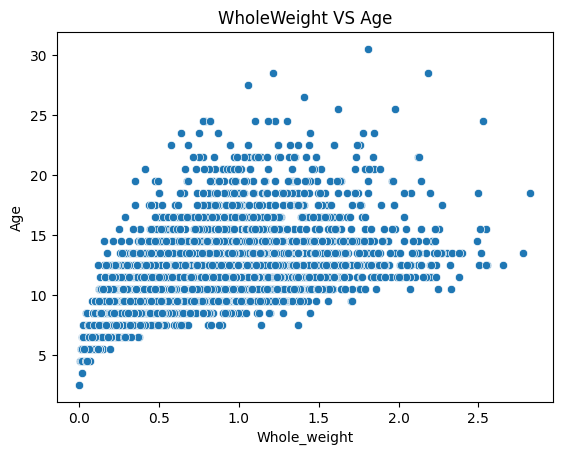

In [153]:
sns.scatterplot(df,x='Whole_weight',y='Age')
plt.title('WholeWeight VS Age')
plt.show()

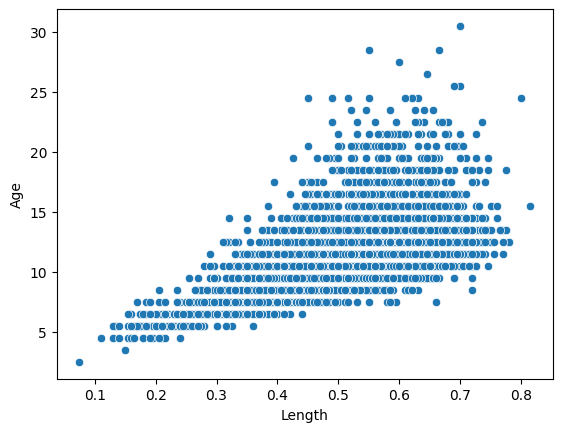

In [154]:
sns.scatterplot(
    data=df,
    x='Length',
    y='Age'
)
plt.show()

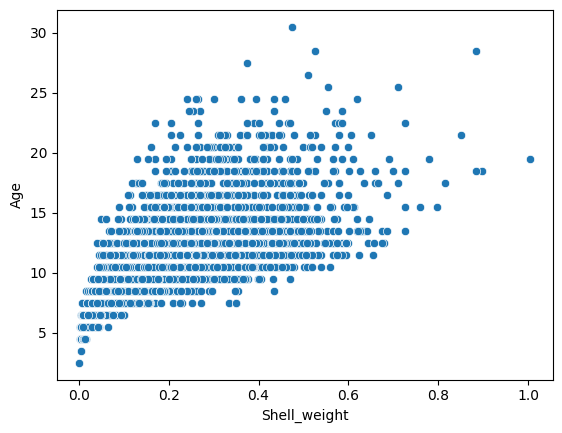

In [155]:
sns.scatterplot(
    data=df,
    x='Shell_weight',
    y='Age'
)
plt.show()

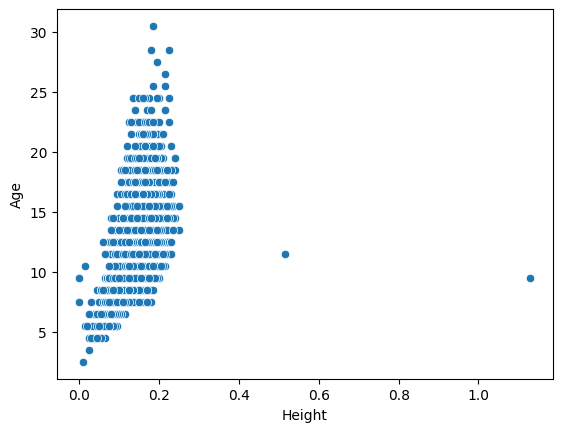

In [156]:
sns.scatterplot(
    data=df,
    x='Height',
    y='Age'
)
plt.show()

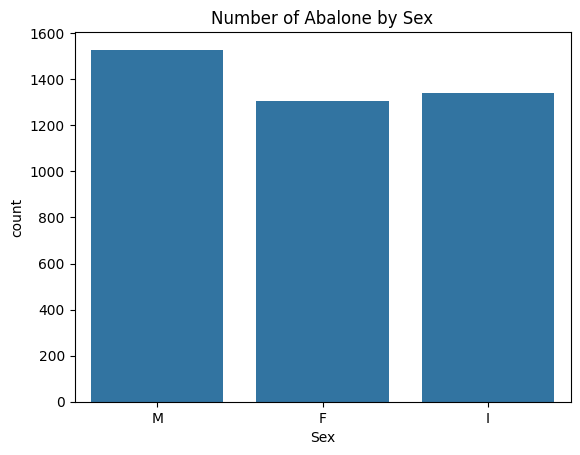

In [157]:
sns.countplot(data=df, x='Sex')

plt.title('Number of Abalone by Sex')
plt.show()

<Axes: xlabel='Sex', ylabel='Age'>

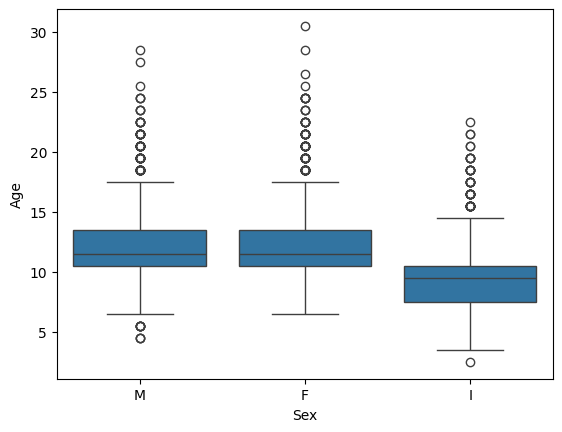

In [158]:
sns.boxplot(data=df, x='Sex', y='Age')
#to see if sex(categorical feature) affects the age or not

See the relation between Columns

In [159]:
df['Shucked_Weight_Ratio'] = df['Shucked_weight'] / df['Whole_weight']
df['Shell_Weight_Ratio'] = df['Shell_weight'] / df['Whole_weight']
df['Viscera_Weight_Ratio'] = df['Viscera_weight'] / df['Whole_weight']
df['Volume_Approx'] = df['Length'] * df['Diameter'] * df['Height']

Encoding

In [160]:
df=pd.get_dummies(df,columns=['Sex'],drop_first=True)

Check for Outliers

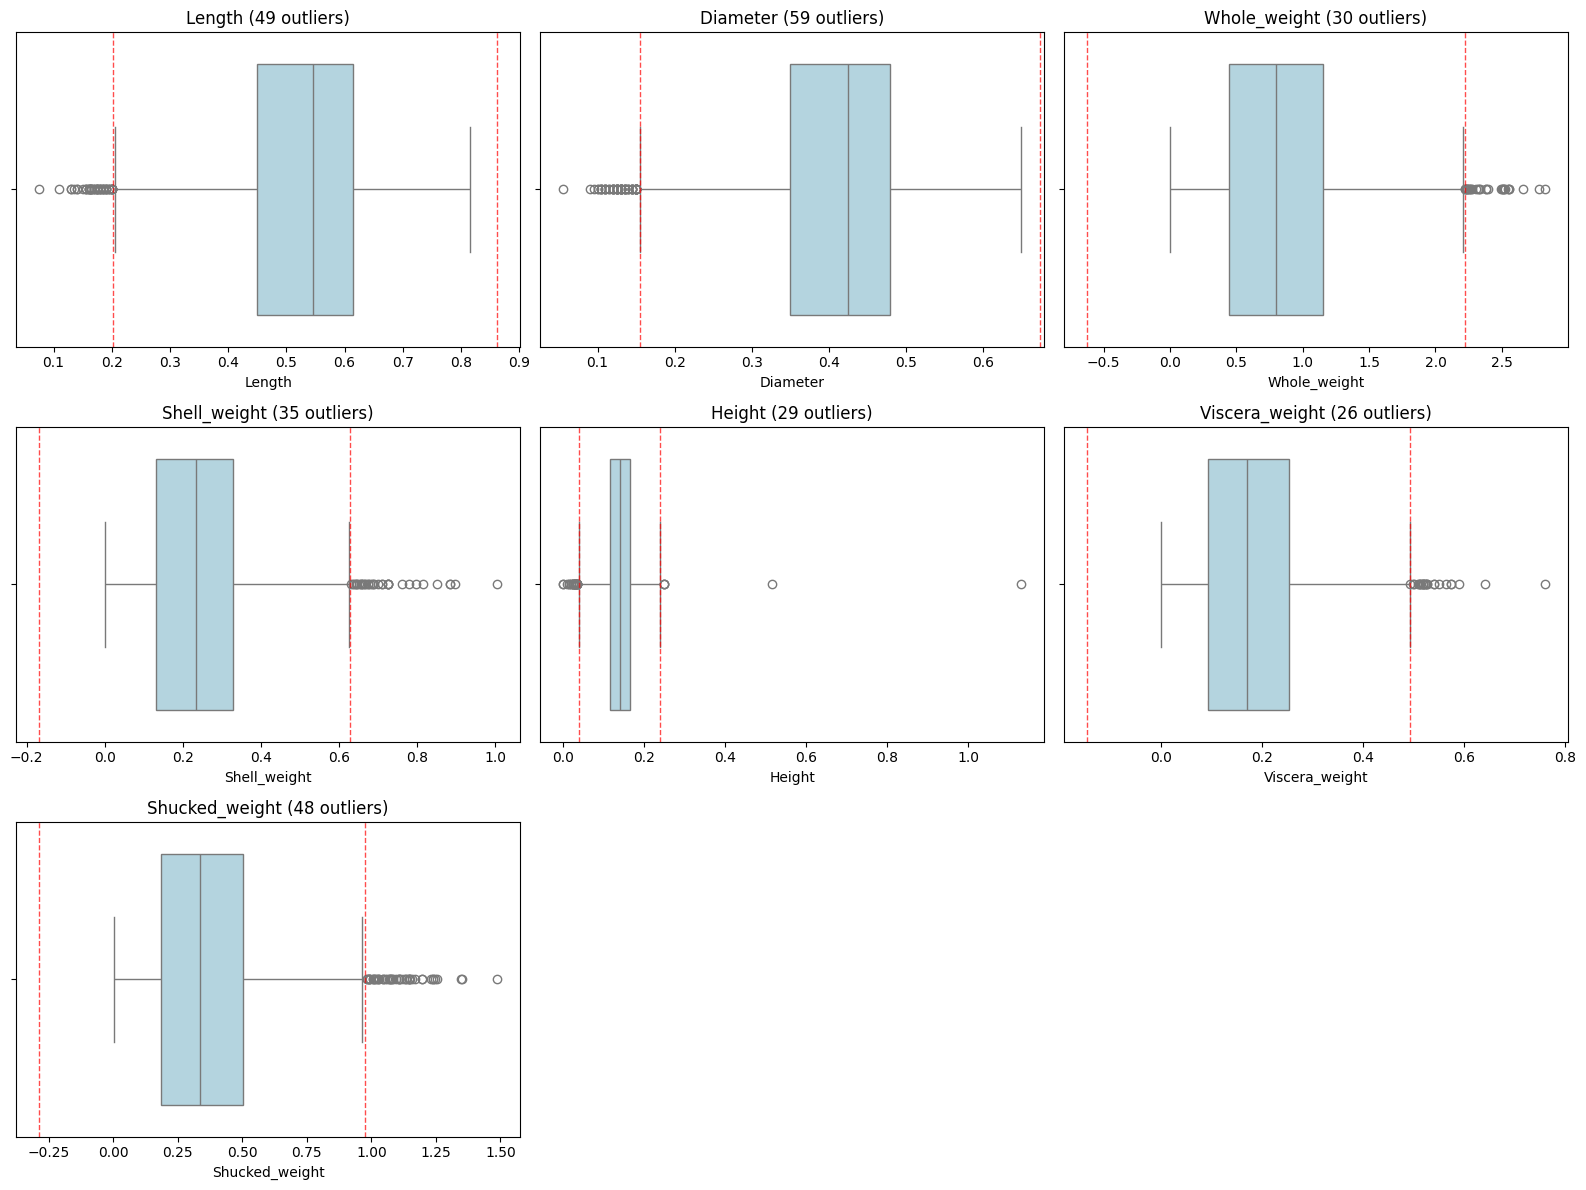

In [161]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    is_outlier = (df[col] < lower) | (df[col] > upper)

    sns.boxplot(x=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'{col} ({is_outlier.sum()} outliers)')
    axes[i].axvline(lower, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[i].axvline(upper, color='red', linestyle='--', linewidth=1, alpha=0.7)

# hide unused subplots (7 columns in a 3x3 grid)
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Features and Target

In [162]:
#understand feature and targets
X=df.drop(columns=['Rings','Age'])
y=df['Age']

Train/Test/Split

In [163]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Standerdization

In [164]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

LinearRegressionmodel

In [165]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test,y_pred)
mse_lr = mean_squared_error(y_test,y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test,y_pred)
print('mae_lr' , mae_lr)
print('mse_lr' , mse_lr)
print('rmse_lr' , rmse_lr)
print('r2_lr' , r2_lr)

mae_lr 1.6523041629826016
mse_lr 8.317731331035604
rmse_lr 2.8840477338344463
r2_lr 0.23163326198469236


Polyregression

In [166]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
mae_poly = mean_absolute_error(y_test,y_pred_poly)
mse_poly = mean_squared_error(y_test,y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test,y_pred_poly)
print('mae_poly' , mae_poly)
print('mse_poly' , mse_poly)
print('rmse_poly' , rmse_poly)
print('r2_poly' , r2_poly)

mae_poly 1.9319217929868202
mse_poly 76.99137286855812
rmse_poly 8.774472797186057
r2_poly -6.112229004753005


DecisionTree

In [167]:
dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test,y_pred_dt)
mse_dt = mean_squared_error(y_test,y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test,y_pred_dt)
print('mae_dt' , mae_dt)
print('mse_dt' , mse_dt)
print('rmse_dt' , rmse_dt)
print('r2_dt' , r2_dt)

mae_dt 1.5676313732629399
mse_dt 4.936349361686261
rmse_dt 2.221789675393749
r2_dt 0.5439950503582114


RandomForest

In [168]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test,y_pred_rf)
mse_rf = mean_squared_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test,y_pred_rf)
print('mae_rf' , mae_rf)
print('mse_rf' , mse_rf)
print('rmse_rf' , rmse_rf)
print('r2_rf' , r2_rf)

mae_rf 1.4984050372024942
mse_rf 4.469410168819048
rmse_rf 2.1140979562969755
r2_rf 0.5871294736998476


Gradient Boosting

In [169]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print('mae_gb', mae_gb)
print('mse_gb', mse_gb)
print('rmse_gb', rmse_gb)
print('r2_gb', r2_gb)

mae_gb 1.4955627621222418
mse_gb 4.459532289754071
rmse_gb 2.1117604716809315
r2_gb 0.5880419621433426


Compare Models

In [170]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'MAE': [
        mae_lr,
        mae_poly,
        mae_dt,
        mae_rf,
        mae_gb

    ],

    'RMSE': [
        rmse_lr,
        rmse_poly,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],

    'R2': [
        r2_lr,
        r2_poly,
        r2_dt,
        r2_rf,
        r2_gb
    ],

    'MSE': [
        mse_lr,
        mse_poly,
        mse_dt,
        mse_rf,
        mse_gb
    ]
})

results

,Model,MAE,RMSE,R2,MSE
0,Linear Regression,1.652304,2.884048,0.231633,8.317731
1,Polynomial Regression,1.931922,8.774473,-6.112229,76.991373
2,Decision Tree,1.567631,2.221790,0.543995,4.936349
3,Random Forest,1.498405,2.114098,0.587129,4.469410
4,Gradient Boosting,1.495563,2.111760,0.588042,4.459532


In [171]:
results.sort_values('R2', ascending=False)

,Model,MAE,RMSE,R2,MSE
4,Gradient Boosting,1.495563,2.111760,0.588042,4.459532
3,Random Forest,1.498405,2.114098,0.587129,4.469410
2,Decision Tree,1.567631,2.221790,0.543995,4.936349
0,Linear Regression,1.652304,2.884048,0.231633,8.317731
1,Polynomial Regression,1.931922,8.774473,-6.112229,76.991373


Check for Overfitting and Underfitting

In [172]:
models = {
    'Linear Regression': (model, X_train_scaled, X_test_scaled),
    'Polynomial Regression': (poly_model, X_train_poly, X_test_poly),
    'Decision Tree': (dt, X_train, X_test),
    'Random Forest': (rf, X_train, X_test),
    'Gradient Boosting': (gb, X_train, X_test)
}
print(f"{'Model':22s} {'Train R2':>10s} {'Test R2':>10s} {'Gap':>8s} {'Status':>15s}")
print("-" * 70)
for name, (m, X_tr, X_te) in models.items():
    train_r2 = r2_score(y_train, m.predict(X_tr))
    test_r2 = r2_score(y_test, m.predict(X_te))
    gap = train_r2 - test_r2
    if train_r2 < 0.60 and test_r2 < 0.60:
        status = "Underfitting"
    elif gap > 0.10:
        status = "Overfitting"
    else:
        status = "Good / Balanced"

    print(f"{name:22s} {train_r2:10.3f} {test_r2:10.3f} {gap:8.3f} {status:>15s}")

Model                    Train R2    Test R2      Gap          Status
----------------------------------------------------------------------
Linear Regression           0.555      0.232    0.323    Underfitting
Polynomial Regression       0.603     -6.112    6.716     Overfitting
Decision Tree               0.596      0.544    0.052    Underfitting
Random Forest               0.831      0.587    0.243     Overfitting
Gradient Boosting           0.682      0.588    0.094 Good / Balanced


Plot relation bet Actual VS Predicted Age after choosing best Model

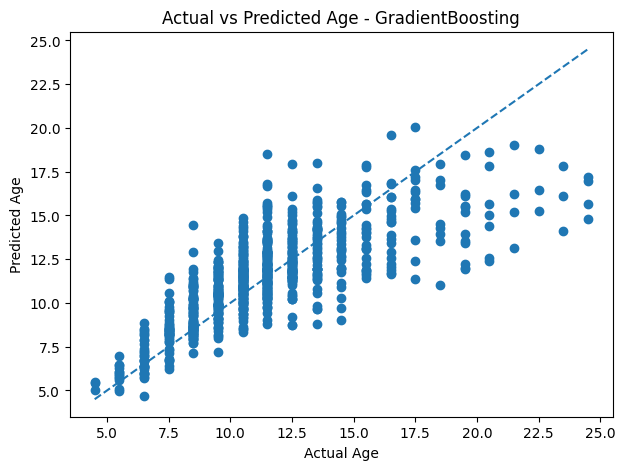

In [174]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_gb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual vs Predicted Age - GradientBoosting')
plt.show()